# Hardness Testing Beispiel

- Eine Härteprüfmaschine drückt einen Stab mit einer spitzen Prüfspitze unter einer definierten Kraft in eine Metallprobe.
- Als Messgröße wird die Tiefe der durch die Spitze verursachten Eindrückung bestimmt.
- Für die Prüfung stehen zwei unterschiedliche Prüfspitzen zur Verfügung.
- Die verwendeten Metallproben stammen aus verschiedenen Materialchargen, wodurch zusätzliche Variabilität entsteht.
- Es stehen 10 Proben zur Verfügung, wobei jede Probe mit beiden Prüfspitzen getestet wird.

Da jede Probe mit beiden Prüfspitzen untersucht wird, liegt ein **gepaartes Versuchsdesign** vor. Zur Analyse der Daten verwenden wir daher einen **gepaarten \(t\)-Test**. Durch die Auswertung der Differenzen innerhalb derselben Probe kann die Streuung zwischen den Materialchargen weitgehend eliminiert und die Vergleichbarkeit der beiden Prüfspitzen verbessert werden.

## Hardness Testing Datengrundlage

![title](../img/table2-6.png)

In [2]:
import pandas as pd

df = pd.DataFrame({
    "Tip1": [
        7, 3, 3, 4, 8,
        3, 2, 9, 5, 4
    ],
    "Tip2": [
        6, 3, 5, 3, 8,
        2, 4, 9, 4, 5
    ]
})

df.index+=1
df.index.name = "Specimen"

df

,Tip1,Tip2
Specimen,,
1,7,6
2,3,3
3,3,5
4,4,3
5,8,8
6,3,2
7,2,4
8,9,9
9,5,4


In [3]:
df["Difference"] = df["Tip1"] - df["Tip2"]

df

,Tip1,Tip2,Difference
Specimen,,,
1,7,6,1
2,3,3,0
3,3,5,-2
4,4,3,1
5,8,8,0
6,3,2,1
7,2,4,-2
8,9,9,0
9,5,4,1


In [4]:
df["Difference"].describe()

count    10.000000
mean     -0.100000
std       1.197219
min      -2.000000
25%      -0.750000
50%       0.000000
75%       1.000000
max       1.000000
Name: Difference, dtype: float64

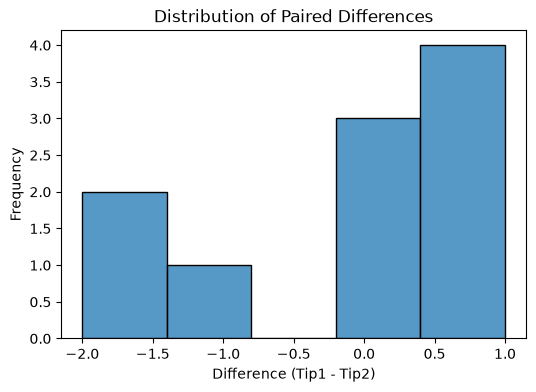

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.histplot(
    df["Difference"],
    bins=5
)

plt.xlabel("Difference (Tip1 - Tip2)")
plt.ylabel("Frequency")
plt.title("Distribution of Paired Differences")

plt.show()

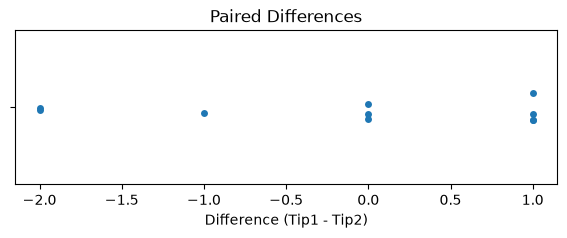

In [15]:
plt.figure(figsize=(7,2))

sns.stripplot(
    x=df["Difference"]
)

plt.xlabel("Difference (Tip1 - Tip2)")
plt.title("Paired Differences")

plt.show()

# Paired $t$-Test

Beim gepaarten $t$-Test betrachten wir nicht die beiden Stichproben getrennt, sondern die Differenzen innerhalb jedes Paares.

Für jede Probe wird die Differenz

$D_i = X_i - Y_i$

berechnet. Anschließend wird untersucht, ob die mittlere Differenz

$\mu_D$

von null verschieden ist.

Die Hypothesen lauten:

$H_0:\mu_D = 0$

$H_1:\mu_D \neq 0$

Die Nullhypothese besagt, dass zwischen den beiden Prüfspitzen im Mittel kein Unterschied besteht. Die Alternativhypothese geht davon aus, dass sich die mittlere Eindringtiefe der beiden Prüfspitzen unterscheidet.

Da die Analyse auf den Differenzen basiert, werden Unterschiede zwischen den einzelnen Proben weitgehend herausgerechnet. Dies reduziert die durch die Materialchargen verursachte Variabilität und erhöht die Empfindlichkeit des Tests.

In [23]:
import numpy as np
from scipy import stats

d = df["Tip1"] - df["Tip2"]

result = stats.ttest_rel(
    df["Tip1"],
    df["Tip2"]
)

mean_diff = d.mean()
sd = d.std(ddof=1)

se = sd / np.sqrt(len(d))

tcrit = stats.t.ppf(0.975, len(d)-1)

ci_lower = mean_diff - tcrit * se
ci_upper = mean_diff + tcrit * se

print("Paired t-Test")
print("-" * 30)
print(f"Mean difference = {mean_diff:.3f}")
print(f"t-statistic     = {result.statistic:.3f}")
print(f"df              = {len(d)-1}")
print(f"p-value         = {result.pvalue:.4f}")
print(f"95% CI          = ({ci_lower:.3f}, {ci_upper:.3f})")

Paired t-Test
------------------------------
Mean difference = -0.100
t-statistic     = -0.264
df              = 9
p-value         = 0.7976
95% CI          = (-0.956, 0.756)


Wir sehen, dass die mittlere Differenz

$\bar{D} = -0.1$

beträgt. Die Prüfspitze **Tip 1** liefert somit im Mittel etwas kleinere Messwerte als **Tip 2**. Dieser Unterschied ist jedoch sehr gering.

Die Teststatistik des gepaarten $t$-Tests beträgt

$t = -0.2641$.

Der zugehörige $p$-Wert ist nicht signifikant, sodass die Nullhypothese nicht verworfen wird.

Die Daten liefern daher keine statistische Evidenz für einen Unterschied zwischen den beiden Prüfspitzen. Die beobachtete mittlere Differenz kann plausibel durch zufällige Stichprobenvariation erklärt werden.

## Einstichproben-$t$-Test

Eine Möglichkeit, einen gepaarten $t$-Test durchzuführen, besteht darin, zunächst eine neue Spalte mit den Differenzen der gepaarten Beobachtungen zu erzeugen und anschließend einen Einstichproben-$t$-Test auf diese Differenzen durchzuführen.

Da der gepaarte $t$-Test mathematisch äquivalent zu einem Einstichproben-$t$-Test auf die Differenzen ist, führen beide Vorgehensweisen zum gleichen Ergebnis.

In [24]:
from scipy import stats

result2 = stats.ttest_1samp(
    df["Difference"],
    popmean=0
)

print("Paired t-Test - Variante 2")
print("-" * 30)
print(f"t-statistic     = {result2.statistic:.3f}")
print(f"p-value         = {result2.pvalue:.4f}")

Paired t-Test - Variante 2
------------------------------
t-statistic     = -0.264
p-value         = 0.7976
